# 第4弾: ADXベースのレジームフィルタ戦略

## 戦略概要

- **ADXレジームフィルタ戦略**: ADX（Average Directional Index）でトレンド強度を測定し、相場環境に応じてミーンリバージョンとトレンドフォローを切り替える手法
- ADX > 25: トレンド相場 → ブレイクアウト（順張り）
- ADX < 25: レンジ相場 → RSI逆張り（ミーンリバージョン）

| 項目 | レンジ相場（ADX < 25） | トレンド相場（ADX > 25） |
|------|----------------------|------------------------|
| ロングエントリー | RSI < 30（売られすぎ） | 終値 > 直近20期間高値 |
| ショートエントリー | RSI > 70（買われすぎ） | 終値 < 直近20期間安値 |
| エグジット | RSI > 50 / RSI < 50 | 直近10期間安値割れ / 高値超え |
| デフォルトパラメータ | RSI期間14、ADX閾値25 | ドンチャン20期間、ADX期間14 |

## 検証対象

- USD/JPY（5分足、スプレッド片道0.002円）
- ETH/JPY（5分足、スプレッド片道=終値平均×0.00005）

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 37.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

- FX（USD_JPY）は `priceType=BID` が必要
- 暗号資産（ETH_JPY）は `priceType` 不要

In [3]:
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",
    "crypto": "https://api.coin.z.com/public/v1/klines",
}

SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"  API: {config['api']} ({base_url})")
    print(f"  期間: {start_date.strftime('%Y-%m-%d')} -> {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")
        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()
            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"  {date_str}: {e}")

        current_date += timedelta(days=1)
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得 ({request_count}リクエスト)")
    print(f"  最初: {df['datetime'].iloc[0]}")
    print(f"  最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [4]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
  API: fx (https://forex-api.coin.z.com/public/v1/klines)
  期間: 2025-04-07 -> 2026-04-07
74,036本取得 (260リクエスト)
  最初: 2025-04-07 07:00:00+09:00
  最後: 2026-04-07 15:50:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-07 07:00:00+09:00,145.494,145.638,144.949,145.132,0.0
1,2025-04-07 07:05:00+09:00,145.139,145.282,144.946,145.118,0.0
2,2025-04-07 07:10:00+09:00,145.118,145.447,145.113,145.346,0.0
3,2025-04-07 07:15:00+09:00,145.346,145.415,145.139,145.263,0.0
4,2025-04-07 07:20:00+09:00,145.261,145.270,145.067,145.239,0.0


### ETH/JPY データ取得

In [5]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
  API: crypto (https://api.coin.z.com/public/v1/klines)
  期間: 2025-04-07 -> 2026-04-07
103,251本取得 (366リクエスト)
  最初: 2025-04-07 06:00:00+09:00
  最後: 2026-04-07 15:55:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-07 06:00:00+09:00,231355.0,232705.0,230666.0,232120.0,350.36
1,2025-04-07 06:05:00+09:00,232159.0,232527.0,231045.0,231260.0,151.00
2,2025-04-07 06:10:00+09:00,231270.0,232666.0,231155.0,232121.0,75.68
3,2025-04-07 06:15:00+09:00,232175.0,233648.0,232172.0,233000.0,117.25
4,2025-04-07 06:20:00+09:00,232966.0,233537.0,232966.0,233270.0,70.28


## 3. テクニカル指標の計算

### ADX（Average Directional Index）

ADXはトレンドの強度を0〜100で表す指標。方向性は持たず、値が大きいほど強いトレンドが出ていることを示す。一般に25以上でトレンド相場、25未満でレンジ相場と判断される。

計算の流れは、まずTrue Rangeから+DI（上昇方向指標）と-DI（下降方向指標）を求め、その差の比率をATRで正規化してDXを算出し、DXを平滑化したものがADXとなる。

### ミーンリバージョン用指標（レンジ相場）

RSI（14期間）。30以下で売られすぎ、70以上で買われすぎ。

### トレンドフォロー用指標（トレンド相場）

ドンチャンチャネル（20期間）。直近20本の最高値・最安値でバンドを形成し、その突破をエントリーシグナルとする。

In [6]:
def calc_adx(df, period=14):
    """ADX（+DI、-DI含む）を計算"""
    high  = df["high"]
    low   = df["low"]
    close = df["close"]

    # True Range
    tr = pd.concat([
        high - low,
        abs(high - close.shift(1)),
        abs(low  - close.shift(1))
    ], axis=1).max(axis=1)

    # 方向性変動
    up   = high - high.shift(1)
    down = low.shift(1) - low

    plus_dm  = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)

    # Wilder平滑化
    atr      = pd.Series(tr).ewm(alpha=1/period, min_periods=period).mean()
    plus_di  = 100 * pd.Series(plus_dm).ewm(alpha=1/period, min_periods=period).mean() / atr
    minus_di = 100 * pd.Series(minus_dm).ewm(alpha=1/period, min_periods=period).mean() / atr

    dx  = 100 * abs(plus_di - minus_di) / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=1/period, min_periods=period).mean()

    return adx, plus_di, minus_di


def calc_rsi(series, period=14):
    """RSIを計算（Wilder's smoothing）"""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def add_adx_regime_indicators(df, adx_period=14, rsi_period=14, dc_period=20, adx_threshold=25):
    """ADXレジームフィルタ戦略用の指標をDataFrameに追加"""
    df = df.copy()

    df["adx"], df["plus_di"], df["minus_di"] = calc_adx(df, period=adx_period)
    df["rsi"]      = calc_rsi(df["close"], period=rsi_period)
    df["dc_upper"] = df["high"].rolling(window=dc_period).max()
    df["dc_lower"] = df["low"].rolling(window=dc_period).min()
    df["dc_exit_upper"] = df["high"].rolling(window=dc_period // 2).max()
    df["dc_exit_lower"] = df["low"].rolling(window=dc_period // 2).min()
    df["is_trend"] = df["adx"] > adx_threshold

    return df.dropna().reset_index(drop=True)


df_usdjpy = add_adx_regime_indicators(df_usdjpy)
df_eth    = add_adx_regime_indicators(df_eth)

print(f"USD/JPY: {len(df_usdjpy):,}本（指標計算後）")
print(f"ETH/JPY: {len(df_eth):,}本（指標計算後）")
print(f"USD/JPY トレンド相場割合: {df_usdjpy['is_trend'].mean()*100:.1f}%")
print(f"ETH/JPY トレンド相場割合: {df_eth['is_trend'].mean()*100:.1f}%")

USD/JPY: 74,010本（指標計算後）
ETH/JPY: 103,225本（指標計算後）
USD/JPY トレンド相場割合: 41.2%
ETH/JPY トレンド相場割合: 41.9%


## 4. バックテスト

In [7]:
def backtest_adx_regime(
    df,
    rsi_oversold=30,
    rsi_overbought=70,
    spread=0.0,
    symbol_name=""
):
    """
    ADXレジームフィルタ戦略のバックテスト（numpy配列化で高速化）。

    レンジ相場（ADX < threshold）:
      - ロング: RSI < rsi_oversold
      - ショート: RSI > rsi_overbought
      - エグジット: RSI が 50 に回帰
    トレンド相場（ADX >= threshold）:
      - ロング: 終値 > 前バーのドンチャン上限
      - ショート: 終値 < 前バーのドンチャン下限
      - エグジット: ドンチャン N/2 期間を逆抜け
    """
    close       = df["close"].to_numpy()
    rsi         = df["rsi"].to_numpy()
    adx         = df["adx"].to_numpy()
    is_trend    = df["is_trend"].to_numpy()
    dc_upper    = df["dc_upper"].to_numpy()
    dc_lower    = df["dc_lower"].to_numpy()
    dc_ex_upper = df["dc_exit_upper"].to_numpy()
    dc_ex_lower = df["dc_exit_lower"].to_numpy()
    datetimes   = df["datetime"].to_numpy()

    position    = 0
    entry_price = 0.0
    entry_time  = None
    entry_mode  = ""   # "mean_rev" or "breakout"
    trades      = []
    equity      = 0.0
    equity_curve = [0.0]

    for i in range(1, len(close)):
        c    = close[i]
        r    = rsi[i]
        trend = is_trend[i]
        prev_dc_up  = dc_upper[i - 1]
        prev_dc_low = dc_lower[i - 1]
        prev_ex_up  = dc_ex_upper[i - 1]
        prev_ex_low = dc_ex_lower[i - 1]

        # --- エントリー ---
        if position == 0:
            if not trend:
                # レンジ相場: ミーンリバージョン
                if r < rsi_oversold:
                    position    = 1
                    entry_price = c + spread
                    entry_time  = datetimes[i]
                    entry_mode  = "mean_rev"
                elif r > rsi_overbought:
                    position    = -1
                    entry_price = c - spread
                    entry_time  = datetimes[i]
                    entry_mode  = "mean_rev"
            else:
                # トレンド相場: ブレイクアウト
                if c > prev_dc_up:
                    position    = 1
                    entry_price = c + spread
                    entry_time  = datetimes[i]
                    entry_mode  = "breakout"
                elif c < prev_dc_low:
                    position    = -1
                    entry_price = c - spread
                    entry_time  = datetimes[i]
                    entry_mode  = "breakout"

        # --- エグジット ---
        elif position == 1:
            exit_signal = (
                (entry_mode == "mean_rev"  and r > 50) or
                (entry_mode == "breakout" and c < prev_ex_low)
            )
            if exit_signal:
                exit_price = c - spread
                pnl = exit_price - entry_price
                trades.append({
                    "entry_time": entry_time, "exit_time": datetimes[i],
                    "direction": "LONG", "mode": entry_mode,
                    "entry_price": entry_price, "exit_price": exit_price,
                    "pnl": pnl, "pnl_pct": pnl / entry_price * 100,
                })
                equity  += pnl
                position = 0

        elif position == -1:
            exit_signal = (
                (entry_mode == "mean_rev"  and r < 50) or
                (entry_mode == "breakout" and c > prev_ex_up)
            )
            if exit_signal:
                exit_price = c + spread
                pnl = entry_price - exit_price
                trades.append({
                    "entry_time": entry_time, "exit_time": datetimes[i],
                    "direction": "SHORT", "mode": entry_mode,
                    "entry_price": entry_price, "exit_price": exit_price,
                    "pnl": pnl, "pnl_pct": pnl / entry_price * 100,
                })
                equity  += pnl
                position = 0

        equity_curve.append(equity)

    # --- 集計 ---
    if not trades:
        print(f"{symbol_name}: トレード0件")
        return {"trades_df": pd.DataFrame(), "equity_curve": equity_curve,
                "total_trades": 0, "symbol": symbol_name}

    tdf = pd.DataFrame(trades)
    wins   = tdf[tdf["pnl"] > 0]
    losses = tdf[tdf["pnl"] <= 0]
    gp = wins["pnl"].sum()        if len(wins)   else 0
    gl = abs(losses["pnl"].sum()) if len(losses) else 0
    pf = gp / gl if gl > 0 else float("inf")
    eq = pd.Series(equity_curve)
    max_dd = (eq - eq.cummax()).min()
    sharpe = (
        tdf["pnl_pct"].mean() / tdf["pnl_pct"].std() * np.sqrt(len(tdf))
        if len(tdf) > 1 and tdf["pnl_pct"].std() > 0 else 0.0
    )
    hold_bars = (
        pd.to_datetime(tdf["exit_time"]) - pd.to_datetime(tdf["entry_time"])
    ).dt.total_seconds() / 300

    # モード別集計
    mr  = tdf[tdf["mode"] == "mean_rev"]
    bo  = tdf[tdf["mode"] == "breakout"]

    res = {
        "symbol": symbol_name, "total_trades": len(tdf),
        "wins": len(wins), "losses": len(losses),
        "win_rate": len(wins) / len(tdf) * 100,
        "total_pnl": tdf["pnl"].sum(), "avg_pnl": tdf["pnl"].mean(),
        "profit_factor": pf, "max_drawdown": max_dd,
        "sharpe_ratio": sharpe, "avg_hold_bars": hold_bars.mean(),
        "trades_df": tdf, "equity_curve": equity_curve,
        "mean_rev_trades": len(mr), "breakout_trades": len(bo),
    }

    print(f"\n{'='*55}")
    print(f"{symbol_name} ADXレジームフィルタ戦略")
    print(f"{'='*55}")
    print(f"  トレード数      : {res['total_trades']} (MR:{res['mean_rev_trades']} / BO:{res['breakout_trades']})")
    print(f"  勝ち / 負け     : {res['wins']} / {res['losses']}")
    print(f"  勝率            : {res['win_rate']:.1f}%")
    print(f"  総損益          : {res['total_pnl']:.4f}")
    print(f"  平均損益        : {res['avg_pnl']:.4f}")
    print(f"  PF              : {res['profit_factor']:.3f}")
    print(f"  最大DD          : {res['max_drawdown']:.4f}")
    print(f"  シャープレシオ  : {res['sharpe_ratio']:.3f}")
    print(f"  平均保有        : {res['avg_hold_bars']:.0f}本（={res['avg_hold_bars']*5:.0f}分）")
    print(f"{'='*55}")
    return res

print("バックテスト関数を定義")

バックテスト関数を定義


### USD/JPY バックテスト

In [8]:
results_usdjpy = backtest_adx_regime(
    df_usdjpy, spread=0.002, symbol_name="USD/JPY"
)


USD/JPY ADXレジームフィルタ戦略
  トレード数      : 1356 (MR:489 / BO:867)
  勝ち / 負け     : 605 / 751
  勝率            : 44.6%
  総損益          : -20.8120
  平均損益        : -0.0153
  PF              : 0.827
  最大DD          : -21.6720
  シャープレシオ  : -2.231
  平均保有        : 31本（=155分）


### ETH/JPY バックテスト

In [9]:
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")

results_eth = backtest_adx_regime(
    df_eth, spread=eth_spread, symbol_name="ETH/JPY"
)

ETH/JPY 推定スプレッド: 23円

ETH/JPY ADXレジームフィルタ戦略
  トレード数      : 1829 (MR:676 / BO:1153)
  勝ち / 負け     : 813 / 1016
  勝率            : 44.5%
  総損益          : -471640.7003
  平均損益        : -257.8681
  PF              : 0.852
  最大DD          : -489137.5547
  シャープレシオ  : -2.323
  平均保有        : 23本（=114分）


## 5. 結果の可視化

In [10]:
def plot_adx_regime_results(results, df, label=""):
    """ADXレジームフィルタ戦略の結果を4分割チャート + 月別損益で可視化"""
    tdf = results["trades_df"]
    if tdf.empty:
        print("トレード0件のためスキップ")
        return
    symbol = results["symbol"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                             gridspec_kw={"height_ratios": [3, 1, 1, 2]})
    fig.suptitle(f"{symbol} ADXレジームフィルタ戦略 {label}", fontsize=16, fontweight="bold")

    # 価格 + エントリーポイント（モード別に色分け）
    ax = axes[0]
    ax.plot(df["datetime"], df["close"], color="black", lw=0.5, alpha=0.8, label="Close")
    mr  = tdf[tdf["mode"] == "mean_rev"]
    bo  = tdf[tdf["mode"] == "breakout"]
    mr_long  = mr[mr["direction"] == "LONG"]
    mr_short = mr[mr["direction"] == "SHORT"]
    bo_long  = bo[bo["direction"] == "LONG"]
    bo_short = bo[bo["direction"] == "SHORT"]
    if len(mr_long):  ax.scatter(mr_long["entry_time"],  mr_long["entry_price"],  marker="^", color="green",  s=25, alpha=0.7, label="MR Long",  zorder=5)
    if len(mr_short): ax.scatter(mr_short["entry_time"], mr_short["entry_price"], marker="v", color="red",    s=25, alpha=0.7, label="MR Short", zorder=5)
    if len(bo_long):  ax.scatter(bo_long["entry_time"],  bo_long["entry_price"],  marker="^", color="blue",   s=25, alpha=0.7, label="BO Long",  zorder=5)
    if len(bo_short): ax.scatter(bo_short["entry_time"], bo_short["entry_price"], marker="v", color="orange", s=25, alpha=0.7, label="BO Short", zorder=5)
    ax.legend(loc="upper left", fontsize=7)
    ax.set_ylabel("Price")
    ax.set_title("価格 + エントリーポイント（緑/赤=MR、青/橙=BO）")

    # ADX
    ax = axes[1]
    ax.plot(df["datetime"], df["adx"], color="purple", lw=0.5, label="ADX")
    ax.axhline(25, color="gray", lw=0.8, ls="--", alpha=0.7, label="ADX=25")
    ax.fill_between(df["datetime"], df["adx"], 25,
                    where=df["adx"] > 25, alpha=0.1, color="purple", label="トレンド相場")
    ax.legend(loc="upper left", fontsize=7)
    ax.set_ylabel("ADX")
    ax.set_title("ADX（25以上でトレンド相場）")

    # 各トレードPnL
    ax = axes[2]
    colors = ["green" if p > 0 else "red" for p in tdf["pnl"]]
    ax.bar(range(len(tdf)), tdf["pnl"], color=colors, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("PnL")
    ax.set_xlabel("Trade #")
    ax.set_title("各トレード損益")

    # エクイティカーブ
    ax = axes[3]
    eq = results["equity_curve"]
    ax.plot(eq, color="navy", lw=1)
    ax.fill_between(range(len(eq)), eq, alpha=0.1, color="navy")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel("累積損益")
    ax.set_xlabel("Bar")
    ax.set_title("エクイティカーブ")

    plt.tight_layout()
    plt.show()

    # 月別損益
    tdf2 = tdf.copy()
    tdf2["month"] = pd.to_datetime(tdf2["entry_time"]).dt.to_period("M")
    monthly = tdf2.groupby("month")["pnl"].sum()
    if len(monthly) > 1:
        fig2, ax2 = plt.subplots(figsize=(14, 3))
        mc = ["green" if v > 0 else "red" for v in monthly.values]
        ax2.bar(range(len(monthly)), monthly.values, color=mc, alpha=0.7)
        ax2.set_xticks(range(len(monthly)))
        ax2.set_xticklabels([str(m) for m in monthly.index], rotation=45, fontsize=8)
        ax2.axhline(0, color="black", lw=0.5)
        ax2.set_title(f"{symbol} 月別損益 {label}")
        ax2.set_ylabel("PnL")
        plt.tight_layout()
        plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果

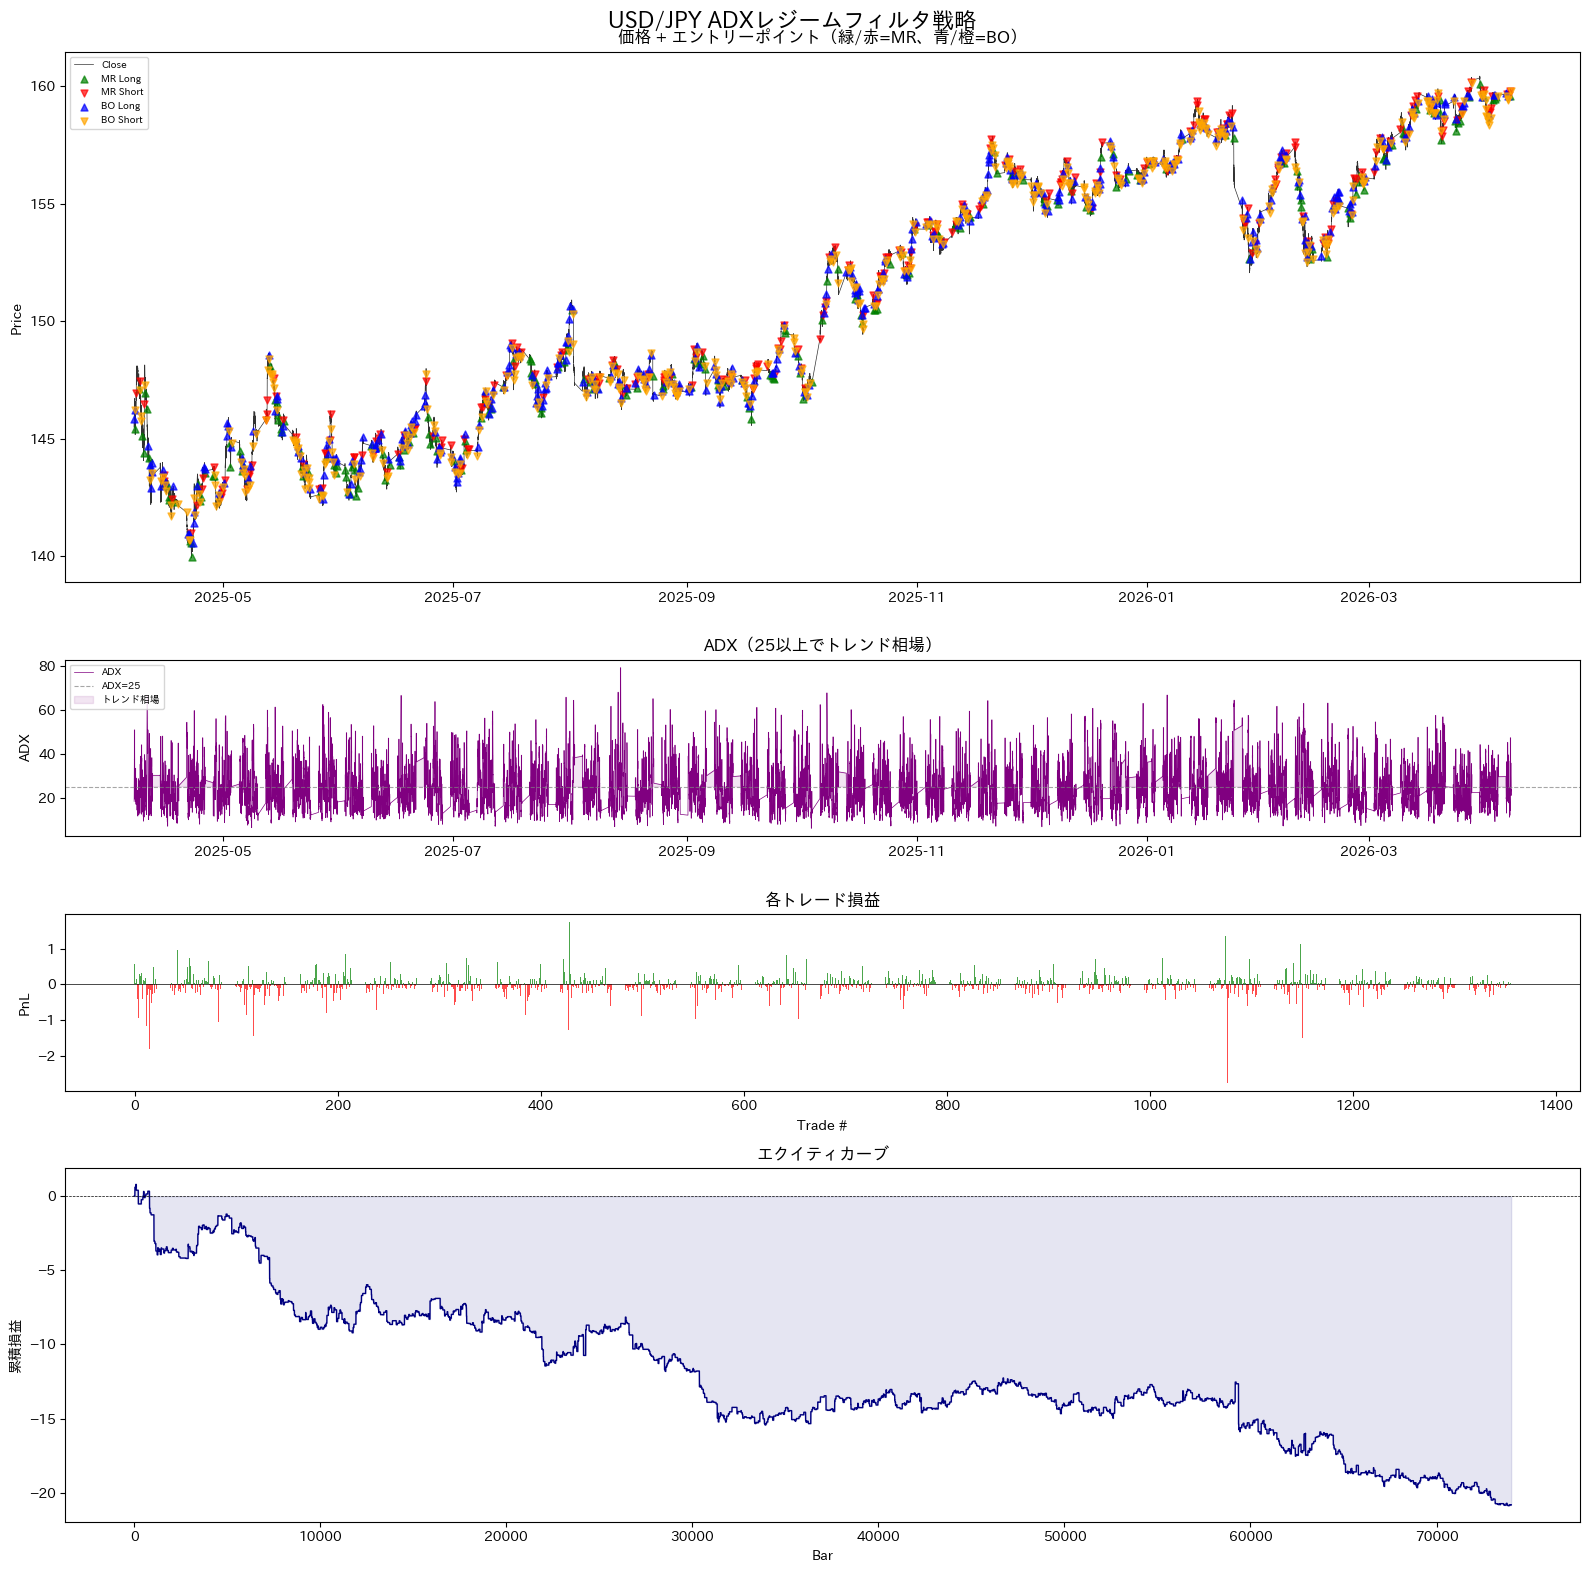

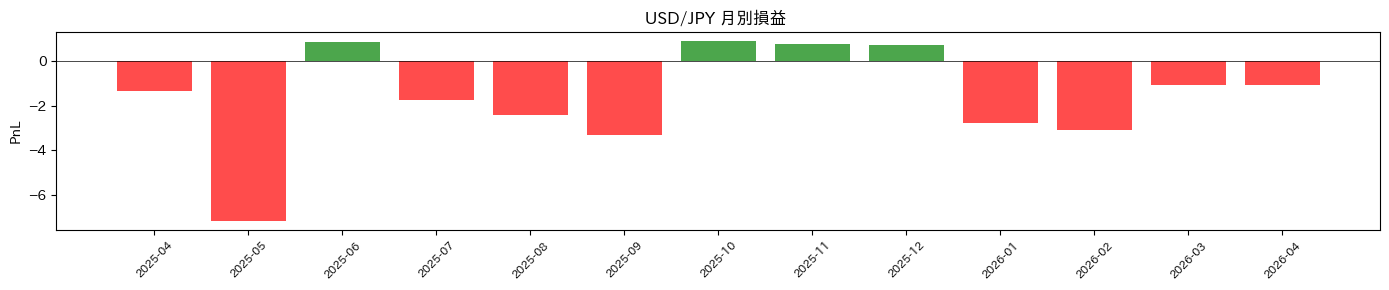

In [11]:
plot_adx_regime_results(results_usdjpy, df_usdjpy)

### ETH/JPY 結果

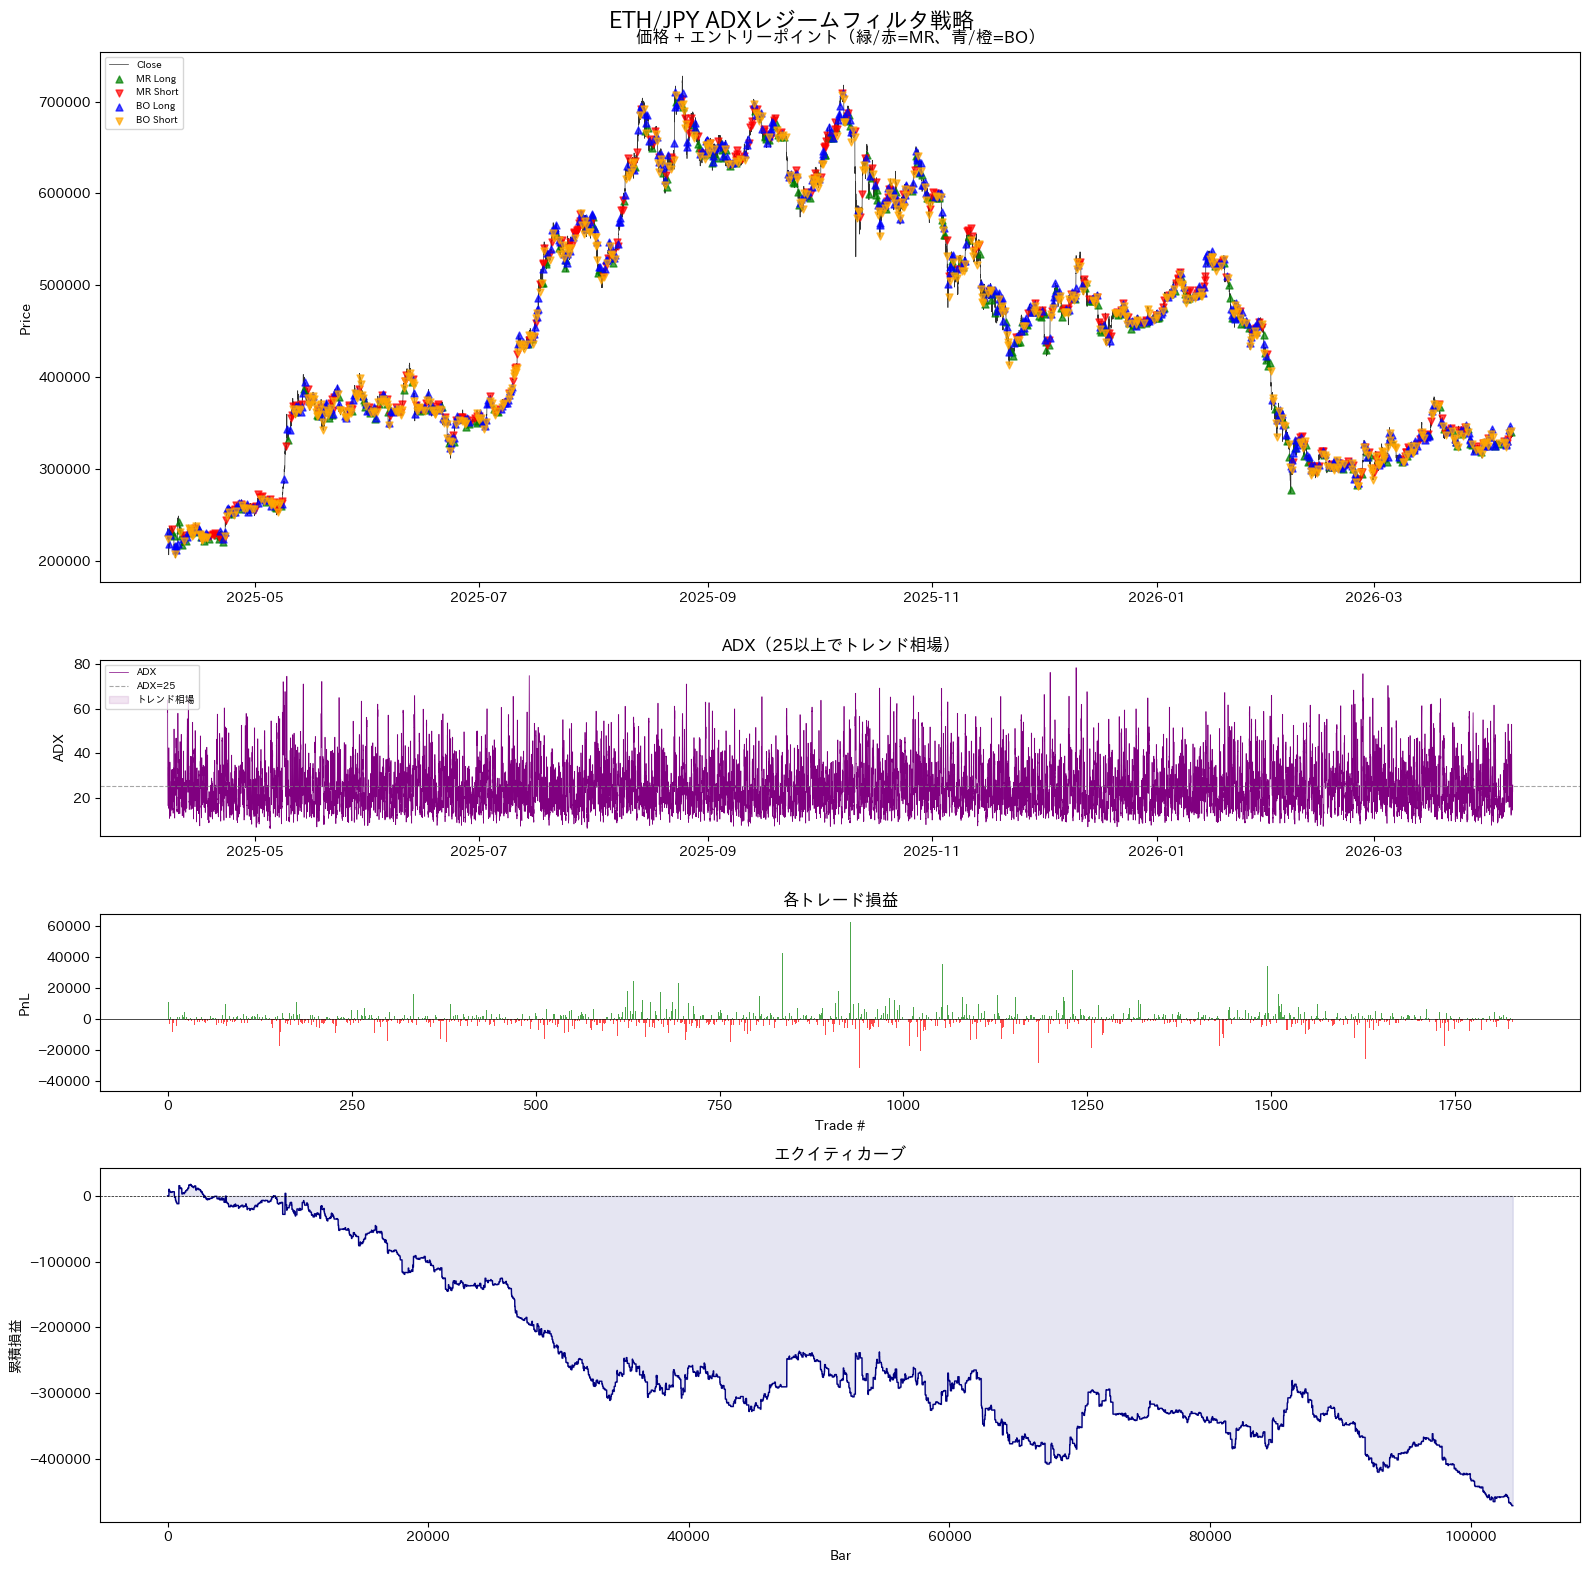

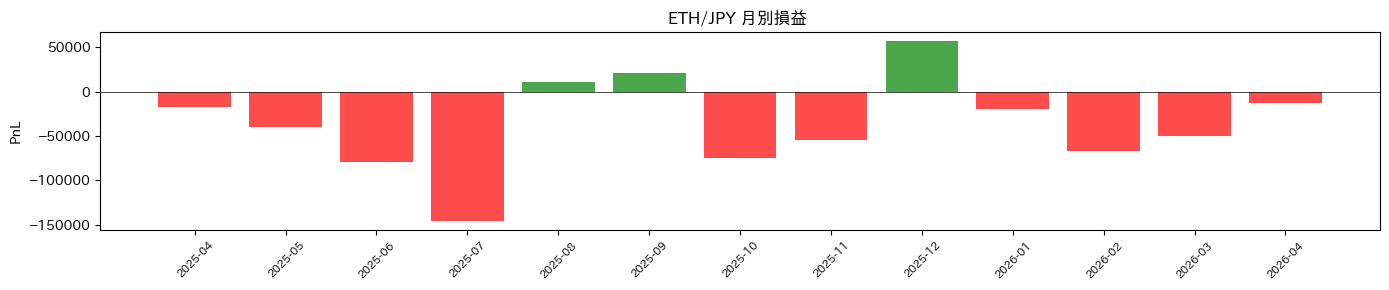

In [12]:
plot_adx_regime_results(results_eth, df_eth)

## 6. パラメータ感度分析

In [13]:
def adx_regime_sensitivity(df_raw, symbol_name, spread):
    """
    ADX閾値 x ADX期間 のグリッドサーチ。
    df_rawは指標計算前の生の5分足DataFrameを渡す。
    """
    adx_thresholds = [20, 25, 30]
    adx_periods    = [10, 14, 20]

    base_cols = ["datetime", "open", "high", "low", "close", "volume"]
    df_base = df_raw[[c for c in base_cols if c in df_raw.columns]].copy()

    total = len(adx_thresholds) * len(adx_periods)
    print(f"{symbol_name} 感度分析中... ({total}パターン)")

    records = []
    for threshold in adx_thresholds:
        for period in adx_periods:
            df_ind = add_adx_regime_indicators(df_base, adx_period=period, adx_threshold=threshold)
            res = backtest_adx_regime(
                df_ind, spread=spread, symbol_name=""
            )
            if res["total_trades"] == 0:
                continue
            records.append({
                "ADX閾値": threshold,
                "ADX期間": period,
                "トレード数": res["total_trades"],
                "MR": res["mean_rev_trades"],
                "BO": res["breakout_trades"],
                "勝率%": round(res["win_rate"], 1),
                "総損益": round(res["total_pnl"], 4),
                "PF": round(res["profit_factor"], 3),
                "最大DD": round(res["max_drawdown"], 4),
            })

    grid = pd.DataFrame(records).sort_values("PF", ascending=False).reset_index(drop=True)
    print(f"\n{symbol_name} TOP10 (PF順):")
    print(grid.head(10).to_string())
    return grid

print("感度分析関数を定義")

感度分析関数を定義


### USD/JPY 感度分析

In [14]:
base_cols = ["datetime", "open", "high", "low", "close", "volume"]
df_usdjpy_raw = df_usdjpy[base_cols].copy()

grid_usdjpy = adx_regime_sensitivity(df_usdjpy_raw, "USD/JPY", spread=0.002)

USD/JPY 感度分析中... (9パターン)

 ADXレジームフィルタ戦略
  トレード数      : 1974 (MR:34 / BO:1940)
  勝ち / 負け     : 718 / 1256
  勝率            : 36.4%
  総損益          : -10.6420
  平均損益        : -0.0054
  PF              : 0.937
  最大DD          : -17.1990
  シャープレシオ  : -0.870
  平均保有        : 33本（=166分）

 ADXレジームフィルタ戦略
  トレード数      : 1678 (MR:197 / BO:1481)
  勝ち / 負け     : 642 / 1036
  勝率            : 38.3%
  総損益          : -19.5410
  平均損益        : -0.0116
  PF              : 0.868
  最大DD          : -22.1680
  シャープレシオ  : -1.903
  平均保有        : 33本（=163分）

 ADXレジームフィルタ戦略
  トレード数      : 1432 (MR:561 / BO:871)
  勝ち / 負け     : 629 / 803
  勝率            : 43.9%
  総損益          : -30.3490
  平均損益        : -0.0212
  PF              : 0.770
  最大DD          : -30.6260
  シャープレシオ  : -3.147
  平均保有        : 32本（=159分）

 ADXレジームフィルタ戦略
  トレード数      : 1669 (MR:143 / BO:1526)
  勝ち / 負け     : 643 / 1026
  勝率            : 38.5%
  総損益          : -11.6950
  平均損益        : -0.0070
  PF              : 0.918
  最大DD          : -13.5300
 

### ETH/JPY 感度分析

In [15]:
eth_spread = df_eth["close"].mean() * 0.00005
df_eth_raw = df_eth[base_cols].copy()

grid_eth = adx_regime_sensitivity(df_eth_raw, "ETH/JPY", spread=eth_spread)

ETH/JPY 感度分析中... (9パターン)

 ADXレジームフィルタ戦略
  トレード数      : 2717 (MR:30 / BO:2687)
  勝ち / 負け     : 909 / 1808
  勝率            : 33.5%
  総損益          : -442357.2098
  平均損益        : -162.8109
  PF              : 0.898
  最大DD          : -527761.5673
  シャープレシオ  : -1.737
  平均保有        : 23本（=116分）

 ADXレジームフィルタ戦略
  トレード数      : 2285 (MR:270 / BO:2015)
  勝ち / 負け     : 825 / 1460
  勝率            : 36.1%
  総損益          : -400175.6376
  平均損益        : -175.1316
  PF              : 0.894
  最大DD          : -454829.5661
  シャープレシオ  : -1.678
  平均保有        : 23本（=116分）

 ADXレジームフィルタ戦略
  トレード数      : 1986 (MR:712 / BO:1274)
  勝ち / 負け     : 885 / 1101
  勝率            : 44.6%
  総損益          : -486951.9638
  平均損益        : -245.1923
  PF              : 0.858
  最大DD          : -523702.9412
  シャープレシオ  : -2.310
  平均保有        : 23本（=113分）

 ADXレジームフィルタ戦略
  トレード数      : 2245 (MR:217 / BO:2028)
  勝ち / 負け     : 785 / 1460
  勝率            : 35.0%
  総損益          : -282312.0290
  平均損益        : -125.7515
  PF            

## 7. 比較サマリー

In [16]:
def get_best_params(grid, min_trades=50):
    filtered = grid[grid["トレード数"] >= min_trades]
    if filtered.empty:
        return None
    return filtered.iloc[0]


def print_summary(results, best, symbol, unit=""):
    print(f"\n{'='*70}")
    print(f"{symbol} ADXレジームフィルタ戦略 最終比較（5分足）")
    print(f"  デフォルト vs 感度分析ベスト（トレード数>=50）")
    print(f"{'='*70}")

    r = results
    print(f"  [デフォルト (ADX閾値25, 期間14)]")
    print(f"    トレード数: {r['total_trades']} (MR:{r['mean_rev_trades']} / BO:{r['breakout_trades']})")
    print(f"    勝率: {r['win_rate']:.1f}%  総損益: {r['total_pnl']:.4f}{unit}  "
          f"PF: {r['profit_factor']:.3f}  最大DD: {r['max_drawdown']:.4f}{unit}")

    if best is not None:
        print(f"  [感度分析TOP (ADX閾値{best['ADX閾値']}, 期間{best['ADX期間']})]")
        print(f"    トレード数: {best['トレード数']} (MR:{best['MR']} / BO:{best['BO']})")
        print(f"    勝率: {best['勝率%']}%  総損益: {best['総損益']}{unit}  "
              f"PF: {best['PF']}  最大DD: {best['最大DD']}{unit}")

    print(f"{'='*70}")
    print("* 感度分析の最適化パラメータはin-sampleの結果。")


best_usdjpy = get_best_params(grid_usdjpy)
best_eth    = get_best_params(grid_eth)

print_summary(results_usdjpy, best_usdjpy, "USD/JPY", unit="円")
print_summary(results_eth,    best_eth,    "ETH/JPY", unit="円")


USD/JPY ADXレジームフィルタ戦略 最終比較（5分足）
  デフォルト vs 感度分析ベスト（トレード数>=50）
  [デフォルト (ADX閾値25, 期間14)]
    トレード数: 1356 (MR:489 / BO:867)
    勝率: 44.6%  総損益: -20.8120円  PF: 0.827  最大DD: -21.6720円
  [感度分析TOP (ADX閾値20.0, 期間10.0)]
    トレード数: 1974.0 (MR:34.0 / BO:1940.0)
    勝率: 36.4%  総損益: -10.642円  PF: 0.937  最大DD: -17.199円
* 感度分析の最適化パラメータはin-sampleの結果。

ETH/JPY ADXレジームフィルタ戦略 最終比較（5分足）
  デフォルト vs 感度分析ベスト（トレード数>=50）
  [デフォルト (ADX閾値25, 期間14)]
    トレード数: 1829 (MR:676 / BO:1153)
    勝率: 44.5%  総損益: -471640.7003円  PF: 0.852  最大DD: -489137.5547円
  [感度分析TOP (ADX閾値30.0, 期間20.0)]
    トレード数: 1479.0 (MR:1201.0 / BO:278.0)
    勝率: 60.0%  総損益: -146787.1256円  PF: 0.943  最大DD: -353156.5709円
* 感度分析の最適化パラメータはin-sampleの結果。
